In [17]:
!pip install ultralytics pycocotools -q

In [18]:
import os
import zipfile
import urllib.request

# ── Config ─────────────────────────────────────────────────────────────────
RUNTIME_DIR  = "/content/coco_val"
IMAGES_DIR   = os.path.join(RUNTIME_DIR, "images")
ANNOT_DIR    = os.path.join(RUNTIME_DIR, "annotations")

os.makedirs(IMAGES_DIR, exist_ok=True)
os.makedirs(ANNOT_DIR,  exist_ok=True)

URLS = {
    "val_images"  : "http://images.cocodataset.org/zips/val2017.zip",
    "annotations" : "http://images.cocodataset.org/annotations/annotations_trainval2017.zip",
}

def download_and_extract(name, url, dest_dir):
    zip_path = os.path.join(dest_dir, os.path.basename(url))
    marker   = zip_path + ".done"

    if os.path.exists(marker):
        print(f"[SKIP] {name} already downloaded.")
    else:
        print(f"[DOWN] Downloading {name} ...")
        def progress(block, block_size, total):
            done = block * block_size
            pct  = min(done * 100 / total, 100) if total > 0 else 0
            print(f"\r       {pct:.1f}%  ({done/1e9:.2f} GB)", end="", flush=True)
        urllib.request.urlretrieve(url, zip_path, reporthook=progress)
        print()
        open(marker, "w").close()
        print(f"[DONE] {name} downloaded.")

    print(f"[EXTR] Extracting {name} ...")
    with zipfile.ZipFile(zip_path, "r") as z:
        z.extractall(dest_dir)
    print(f"[DONE] {name} extracted.")

download_and_extract("val images",   URLS["val_images"],   IMAGES_DIR)
download_and_extract("annotations",  URLS["annotations"],  ANNOT_DIR)

# ── Move annotation file to expected path ──────────────────────────────────
import shutil
src = os.path.join(ANNOT_DIR, "annotations", "instances_val2017.json")
dst = os.path.join(ANNOT_DIR, "instances_val2017.json")
if not os.path.exists(dst):
    shutil.move(src, dst)

print("\n── Verification ───────────────────────────────────────────")
img_count = len(os.listdir(os.path.join(IMAGES_DIR, "val2017")))
ann_size  = os.path.getsize(dst) / 1e6
print(f"  ✓ Val images     : {img_count} files")
print(f"  ✓ Annotation file: {ann_size:.1f} MB")
print("───────────────────────────────────────────────────────────")

[SKIP] val images already downloaded.
[EXTR] Extracting val images ...
[DONE] val images extracted.
[SKIP] annotations already downloaded.
[EXTR] Extracting annotations ...
[DONE] annotations extracted.

── Verification ───────────────────────────────────────────
  ✓ Val images     : 5000 files
  ✓ Annotation file: 20.0 MB
───────────────────────────────────────────────────────────


In [19]:
from ultralytics import YOLO
import os

MODEL_PATH = "/content/yolov8n.pt"

if not os.path.exists(MODEL_PATH):
    print("[DOWN] Downloading YOLOv8n ...")
    model = YOLO("yolov8n.pt")  # auto downloads
    os.rename("yolov8n.pt", MODEL_PATH)
else:
    model = YOLO(MODEL_PATH)
    print("[SKIP] Model already exists.")

size_mb = os.path.getsize(MODEL_PATH) / 1e6
print(f"  ✓ Model size : {size_mb:.2f} MB")
print(f"  ✓ Model path : {MODEL_PATH}")

[SKIP] Model already exists.
  ✓ Model size : 6.55 MB
  ✓ Model path : /content/yolov8n.pt


In [20]:
import random
import json

random.seed(42)

VAL_IMG_DIR = os.path.join(IMAGES_DIR, "val2017")
ANNOT_FILE  = os.path.join(ANNOT_DIR, "instances_val2017.json")

# Load annotations
with open(ANNOT_FILE) as f:
    coco_data = json.load(f)

# Sample 500 image ids
all_images  = coco_data["images"]
sampled     = random.sample(all_images, 500)
sampled_ids = {img["id"] for img in sampled}

# Full paths
sampled_paths = [
    os.path.join(VAL_IMG_DIR, img["file_name"])
    for img in sampled
]

print(f"  ✓ Sampled {len(sampled_paths)} images for evaluation")

  ✓ Sampled 500 images for evaluation


In [21]:
import torch
import time
import psutil
import os
from ultralytics import YOLO
from pycocotools.coco import COCO
from pycocotools.cocoeval import COCOeval

def run_evaluation(model_path, image_paths, annot_file, class_filter=None):
    """
    Runs inference + computes metrics.
    class_filter : list of COCO category ids to evaluate on (None = all 80)
    """
    model     = YOLO(model_path)
    results_list = []
    latencies    = []

    print(f"\n[EVAL] Running inference on {len(image_paths)} images ...")

    for img_path in image_paths:
        start  = time.perf_counter()
        result = model.predict(img_path, verbose=False, conf=0.001)[0]
        end    = time.perf_counter()
        latencies.append((end - start) * 1000)  # ms

        for box in result.boxes:
            cls_id   = int(box.cls.item())
            coco_id  = model.names[cls_id]

            # Map ultralytics class name → COCO category id
            cat_id = name_to_coco_id.get(model.names[cls_id], None)
            if cat_id is None:
                continue
            if class_filter and cat_id not in class_filter:
                continue

            x1, y1, x2, y2 = box.xyxy[0].tolist()
            results_list.append({
                "image_id"   : img_name_to_id[os.path.basename(img_path)],
                "category_id": cat_id,
                "bbox"       : [x1, y1, x2 - x1, y2 - y1],  # xywh for COCO
                "score"      : float(box.conf.item()),
            })

    # ── mAP via pycocotools ────────────────────────────────────────────────
    coco_gt   = COCO(annot_file)

    if class_filter:
        coco_gt_filtered = coco_gt
        eval_ids = [img_name_to_id[os.path.basename(p)] for p in image_paths
                    if os.path.basename(p) in img_name_to_id]
    else:
        eval_ids = [img_name_to_id[os.path.basename(p)] for p in image_paths
                    if os.path.basename(p) in img_name_to_id]

    if len(results_list) == 0:
        print("  ✗ No detections found.")
        return {}

    coco_dt   = coco_gt.loadRes(results_list)
    coco_eval = COCOeval(coco_gt, coco_dt, "bbox")
    coco_eval.params.imgIds  = eval_ids
    if class_filter:
        coco_eval.params.catIds = class_filter
    coco_eval.evaluate()
    coco_eval.accumulate()
    coco_eval.summarize()

    avg_latency = sum(latencies) / len(latencies)
    fps         = 1000 / avg_latency
    model_size  = os.path.getsize(model_path) / 1e6
    ram_mb      = psutil.Process(os.getpid()).memory_info().rss / 1e6

    return {
        "mAP@0.5"       : round(coco_eval.stats[1], 4),
        "mAP@0.5:0.95"  : round(coco_eval.stats[0], 4),
        "avg_latency_ms": round(avg_latency, 2),
        "fps"           : round(fps, 2),
        "model_size_mb" : round(model_size, 2),
        "ram_usage_mb"  : round(ram_mb, 2),
    }

In [22]:
# ── Image name → COCO image id ────────────────────────────────────────────
img_name_to_id = {img["file_name"]: img["id"] for img in coco_data["images"]}

# ── Ultralytics class name → COCO category id ─────────────────────────────
coco_gt_full    = COCO(ANNOT_FILE)
coco_categories = {cat["name"]: cat["id"] for cat in coco_gt_full.loadCats(coco_gt_full.getCatIds())}

model_check     = YOLO(MODEL_PATH)
name_to_coco_id = {}
for idx, name in model_check.names.items():
    if name in coco_categories:
        name_to_coco_id[name] = coco_categories[name]

print(f"  ✓ Mapped {len(name_to_coco_id)} ultralytics classes → COCO ids")

# ── Our 3 class COCO ids ───────────────────────────────────────────────────
OUR_CLASSES     = ["laptop", "tv", "cell phone"]
OUR_COCO_IDS    = [coco_categories[c] for c in OUR_CLASSES]
print(f"  ✓ Our 3 class COCO ids: {dict(zip(OUR_CLASSES, OUR_COCO_IDS))}")

loading annotations into memory...
Done (t=0.70s)
creating index...
index created!
  ✓ Mapped 80 ultralytics classes → COCO ids
  ✓ Our 3 class COCO ids: {'laptop': 73, 'tv': 72, 'cell phone': 77}


In [23]:
print("=" * 60)
print("  EVALUATION 1 : All 80 classes")
print("=" * 60)
metrics_80 = run_evaluation(MODEL_PATH, sampled_paths, ANNOT_FILE)

print("\n" + "=" * 60)
print("  EVALUATION 2 : 3 classes only (laptop, tv, phone)")
print("=" * 60)
metrics_3  = run_evaluation(MODEL_PATH, sampled_paths, ANNOT_FILE,
                             class_filter=OUR_COCO_IDS)

  EVALUATION 1 : All 80 classes

[EVAL] Running inference on 500 images ...
loading annotations into memory...
Done (t=0.60s)
creating index...
index created!
Loading and preparing results...
DONE (t=0.61s)
creating index...
index created!
Running per image evaluation...
Evaluate annotation type *bbox*
DONE (t=8.62s).
Accumulating evaluation results...
DONE (t=1.41s).
 Average Precision  (AP) @[ IoU=0.50:0.95 | area=   all | maxDets=100 ] = 0.389
 Average Precision  (AP) @[ IoU=0.50      | area=   all | maxDets=100 ] = 0.540
 Average Precision  (AP) @[ IoU=0.75      | area=   all | maxDets=100 ] = 0.426
 Average Precision  (AP) @[ IoU=0.50:0.95 | area= small | maxDets=100 ] = 0.231
 Average Precision  (AP) @[ IoU=0.50:0.95 | area=medium | maxDets=100 ] = 0.428
 Average Precision  (AP) @[ IoU=0.50:0.95 | area= large | maxDets=100 ] = 0.587
 Average Recall     (AR) @[ IoU=0.50:0.95 | area=   all | maxDets=  1 ] = 0.309
 Average Recall     (AR) @[ IoU=0.50:0.95 | area=   all | maxDets= 10

In [24]:
import pandas as pd

rows = {
    "Metric"         : ["mAP@0.5", "mAP@0.5:0.95", "Avg Latency (ms)", "FPS", "Model Size (MB)", "RAM Usage (MB)"],
    "80 Classes"     : [metrics_80.get(k, "-") for k in ["mAP@0.5","mAP@0.5:0.95","avg_latency_ms","fps","model_size_mb","ram_usage_mb"]],
    "3 Classes Only" : [metrics_3.get(k,  "-") for k in ["mAP@0.5","mAP@0.5:0.95","avg_latency_ms","fps","model_size_mb","ram_usage_mb"]],
}

df = pd.DataFrame(rows)
df.set_index("Metric", inplace=True)
print(df.to_string())

                  80 Classes  3 Classes Only
Metric                                      
mAP@0.5               0.5395          0.7111
mAP@0.5:0.95          0.3890          0.5494
Avg Latency (ms)    205.7900        192.9000
FPS                   4.8600          5.1800
Model Size (MB)       6.5500          6.5500
RAM Usage (MB)     1208.7600       1087.2000


Target class IDs: [63, 62, 67]
img_4.jpg → 244.85 ms


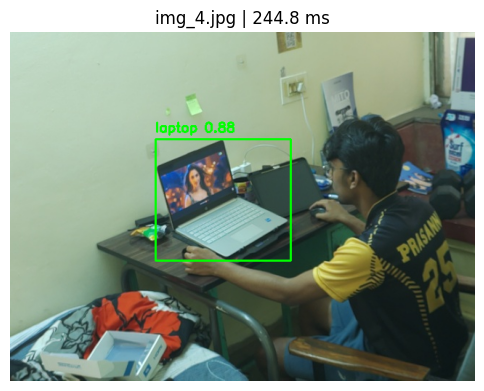

img_8.jpg → 195.97 ms


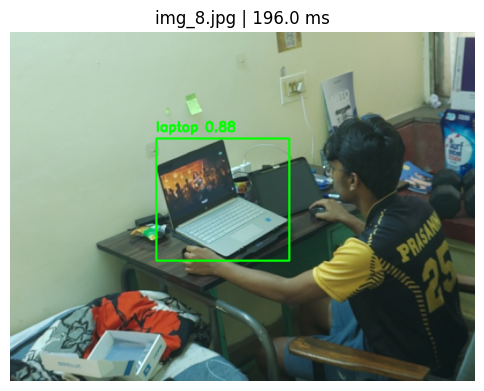

img_9.jpg → 197.02 ms


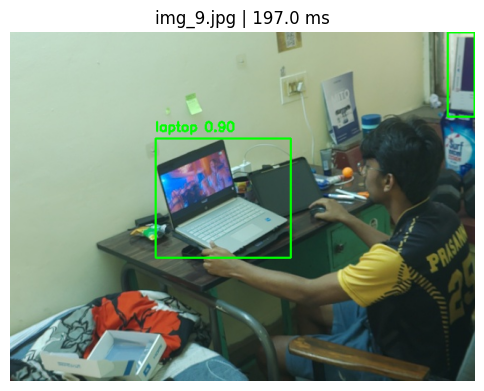

img_7.jpg → 193.59 ms


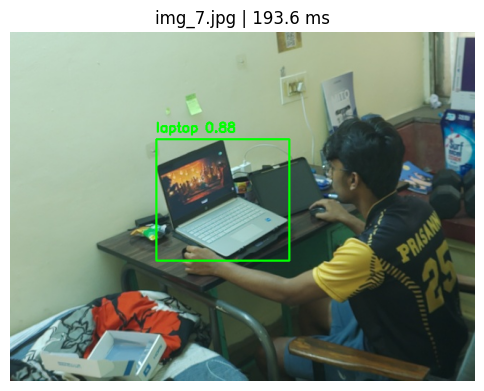

img_6.jpg → 195.91 ms


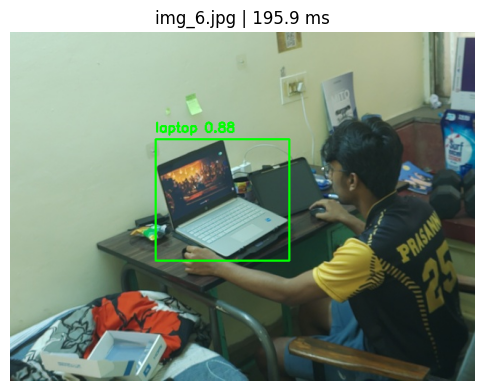

img_5.jpg → 218.06 ms


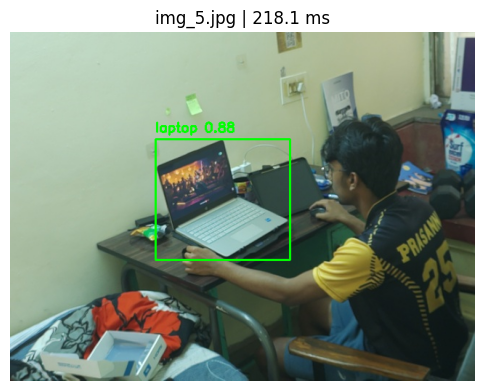

img_31.jpg → 193.24 ms


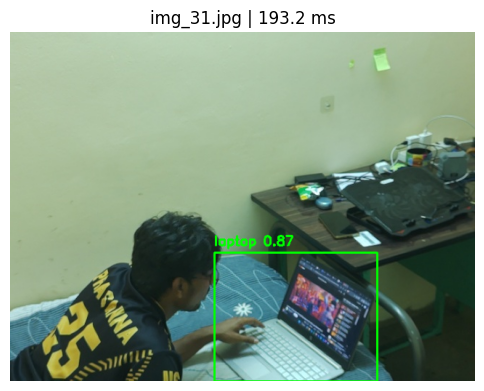


Average Latency : 205.52 ms
FPS             : 4.87


In [25]:
import cv2
import matplotlib.pyplot as plt
import os
import time
from ultralytics import YOLO

# ── CONFIG ─────────────────────────────────────────────
IMAGE_DIR = "myimages"
MODEL_PATH = "/content/yolov8n.pt"
TARGET_CLASSES = ["laptop", "tv", "cell phone"]

# ── LOAD MODEL ─────────────────────────────────────────
model = YOLO(MODEL_PATH)

name_to_id = {v: k for k, v in model.names.items()}
target_ids = [name_to_id[c] for c in TARGET_CLASSES if c in name_to_id]

print("Target class IDs:", target_ids)

# ── INFERENCE + TIMING ─────────────────────────────────
image_files = [f for f in os.listdir(IMAGE_DIR) if f.endswith((".jpg", ".png", ".jpeg"))]

latencies = []

for img_name in image_files:
    img_path = os.path.join(IMAGE_DIR, img_name)

    # ⏱️ Start timing
    start = time.perf_counter()

    result = model.predict(img_path, conf=0.5, iou=0.5, max_det=10, verbose=False)[0]

    # ⏱️ End timing
    end = time.perf_counter()

    latency_ms = (end - start) * 1000
    latencies.append(latency_ms)

    print(f"{img_name} → {latency_ms:.2f} ms")

    img = cv2.imread(img_path)

    for box in result.boxes:
        cls = int(box.cls.item())
        if cls not in target_ids:
            continue

        x1, y1, x2, y2 = map(int, box.xyxy[0].tolist())
        conf = box.conf.item()
        label = model.names[cls]

        cv2.rectangle(img, (x1, y1), (x2, y2), (0, 255, 0), 2)
        cv2.putText(img, f"{label} {conf:.2f}",
                    (x1, y1 - 10),
                    cv2.FONT_HERSHEY_SIMPLEX,
                    0.6, (0, 255, 0), 2)

    # Convert for display
    img_rgb = cv2.cvtColor(img, cv2.COLOR_BGR2RGB)

    plt.figure(figsize=(6,6))
    plt.imshow(img_rgb)
    plt.title(f"{img_name} | {latency_ms:.1f} ms")
    plt.axis("off")
    plt.show()

# ── FINAL METRICS ──────────────────────────────────────
avg_latency = sum(latencies) / len(latencies)
fps = 1000 / avg_latency

print("\n" + "="*40)
print(f"Average Latency : {avg_latency:.2f} ms")
print(f"FPS             : {fps:.2f}")
print("="*40)

In [26]:
# ============================================================
# 🔬 QUANTIZATION EXPERIMENT BLOCK (UPDATED - APPEND ONLY)
# ============================================================

from ultralytics import YOLO
import os
import pandas as pd
from onnxruntime.quantization import quantize_dynamic, QuantType

BASE_MODEL = "/content/yolov8n.pt"

# ── 1. EXPORT MODELS (FP32 + FP16 ONLY) ─────────────────────
print("\n[STEP 1] Exporting model variants...")

export_configs = [
    ("fp32", {"format": "onnx"}),
    ("fp16", {"format": "onnx", "half": True})
]

exported_models = {}

for name, cfg in export_configs:
    out_path = f"/content/yolov8n_{name}.onnx"

    if not os.path.exists(out_path):
        print(f"  → Exporting {name}...")
        model = YOLO(BASE_MODEL)
        model.export(**cfg)
        os.rename("/content/yolov8n.onnx", out_path)
    else:
        print(f"  ✓ {name} already exists")

    exported_models[name] = out_path


# ── 2. INT8 QUANTIZATION (CORRECT WAY) ─────────────────────
print("\n[STEP 2] Creating INT8 model...")

fp32_model = "/content/yolov8n_fp32.onnx"
int8_model = "/content/yolov8n_int8.onnx"

if not os.path.exists(int8_model):
    quantize_dynamic(
        model_input=fp32_model,
        model_output=int8_model,
        weight_type=QuantType.QInt8
    )
    print("  ✓ INT8 model created")
else:
    print("  ✓ INT8 model already exists")

exported_models["int8"] = int8_model

# Add PyTorch baseline
exported_models["pytorch_fp32"] = BASE_MODEL


# ── 3. RUN EXPERIMENTS ─────────────────────────────────────
print("\n[STEP 3] Running experiments...\n")

results = []

for name, path in exported_models.items():

    print("="*60)
    print(f"MODEL: {name}")
    print("="*60)

    # 80 classes
    print("\n→ Evaluating 80 classes")
    m80 = run_evaluation(path, sampled_paths, ANNOT_FILE)

    # 3 classes
    print("\n→ Evaluating 3 classes")
    m3 = run_evaluation(path, sampled_paths, ANNOT_FILE,
                        class_filter=OUR_COCO_IDS)

    results.append({
        "Model": name,
        "Latency(ms)": m80.get("avg_latency_ms", "-"),
        "FPS": m80.get("fps", "-"),
        "mAP@0.5 (80)": m80.get("mAP@0.5", "-"),
        "mAP@0.5 (3)": m3.get("mAP@0.5", "-"),
        "Model Size (MB)": m80.get("model_size_mb", "-"),
        "RAM (MB)": m80.get("ram_usage_mb", "-"),
    })


# ── 4. FINAL COMPARISON TABLE ─────────────────────────────
print("\n" + "="*70)
print("📊 FINAL QUANTIZATION COMPARISON")
print("="*70)

df = pd.DataFrame(results)
print(df.to_string(index=False))


# ── 5. SORTED VIEW ───────────────────────────────────────
print("\n🚀 Sorted by Latency (fastest first):\n")

try:
    df_sorted = df.sort_values(by="Latency(ms)")
    print(df_sorted.to_string(index=False))
except:
    print("Sorting skipped (non-numeric values present)")

ModuleNotFoundError: No module named 'onnxruntime'

In [ ]:
# ============================================================
# ⚡ TRUE ONNX RUNTIME BENCHMARK (FIXED INPUT SIZE)
# ============================================================

import onnxruntime as ort
import numpy as np
import cv2
import time
import os

print("\n[ONNX RUNTIME TEST - REAL DEPLOYMENT SIMULATION]\n")

# ── MODELS ─────────────────────────────────────────────
onnx_models = {
    "fp32": "/content/yolov8n_fp32.onnx",
    "fp16": "/content/yolov8n_fp16.onnx",
    "int8": "/content/yolov8n_int8.onnx"
}

# ── PREPROCESS (FIXED TO 640 TO MATCH EXPORT) ───────────
def preprocess(img_path, size=640):
    img = cv2.imread(img_path)
    img = cv2.resize(img, (size, size))
    img = img / 255.0
    img = img.transpose(2, 0, 1)
    img = np.expand_dims(img, axis=0).astype(np.float32)
    return img

# ── BENCHMARK ──────────────────────────────────────────
rt_results = []

for name, model_path in onnx_models.items():

    print("="*50)
    print(f"MODEL: {name} (ONNX Runtime)")
    print("="*50)

    session = ort.InferenceSession(
        model_path,
        providers=["CPUExecutionProvider"]
    )

    input_name = session.get_inputs()[0].name

    latencies = []

    for img_path in sampled_paths[:200]:   # subset for speed
        inp = preprocess(img_path, size=640)   # FIXED HERE

        start = time.perf_counter()
        _ = session.run(None, {input_name: inp})
        end = time.perf_counter()

        latencies.append((end - start) * 1000)

    avg_latency = sum(latencies) / len(latencies)
    fps = 1000 / avg_latency

    print(f"\nLatency : {avg_latency:.2f} ms")
    print(f"FPS     : {fps:.2f}")

    rt_results.append({
        "Model": name,
        "Latency(ms)": round(avg_latency, 2),
        "FPS": round(fps, 2)
    })

# ── FINAL COMPARISON ───────────────────────────────────
import pandas as pd

print("\n" + "="*60)
print("🚀 ONNX RUNTIME (DEPLOYMENT) COMPARISON")
print("="*60)

df_rt = pd.DataFrame(rt_results)
print(df_rt.to_string(index=False))

In [ ]:
# ============================================================
# 🔥 STATIC INT8 QUANTIZATION (CALIBRATION BASED)
# ============================================================

from onnxruntime.quantization import quantize_static, CalibrationDataReader, QuantType, QuantFormat
import numpy as np
import cv2
import onnxruntime as ort
import time
import os
import pandas as pd

print("\n[STATIC INT8 QUANTIZATION START]\n")

FP32_MODEL = "/content/yolov8n_fp32.onnx"
STATIC_INT8_MODEL = "/content/yolov8n_static_int8.onnx"

# ── DATA READER FOR CALIBRATION ─────────────────────────
class YOLODataReader(CalibrationDataReader):
    def __init__(self, image_paths, input_name, size=640):
        self.image_paths = image_paths[:100]   # use subset for calibration
        self.input_name = input_name
        self.size = size
        self.enum_data = None

    def preprocess(self, img_path):
        img = cv2.imread(img_path)
        img = cv2.resize(img, (self.size, self.size))
        img = img / 255.0
        img = img.transpose(2, 0, 1)
        img = np.expand_dims(img, axis=0).astype(np.float32)
        return img

    def get_next(self):
        if self.enum_data is None:
            self.enum_data = iter(self.image_paths)

        try:
            img_path = next(self.enum_data)
            return {self.input_name: self.preprocess(img_path)}
        except StopIteration:
            return None


# ── CREATE STATIC INT8 MODEL ────────────────────────────
if not os.path.exists(STATIC_INT8_MODEL):

    print("Creating STATIC INT8 model...")

    session = ort.InferenceSession(FP32_MODEL)
    input_name = session.get_inputs()[0].name

    data_reader = YOLODataReader(sampled_paths, input_name, size=640)

    quantize_static(
        model_input=FP32_MODEL,
        model_output=STATIC_INT8_MODEL,
        calibration_data_reader=data_reader,
        quant_format=QuantFormat.QDQ,
        weight_type=QuantType.QInt8,
        activation_type=QuantType.QInt8
    )

    print("✓ Static INT8 model created")

else:
    print("✓ Static INT8 model already exists")


# ============================================================
# ⚡ BENCHMARK (REAL ONNX RUNTIME)
# ============================================================

print("\n[STATIC INT8 BENCHMARK]\n")

onnx_models = {
    "fp32": "/content/yolov8n_fp32.onnx",
    "fp16": "/content/yolov8n_fp16.onnx",
    "dynamic_int8": "/content/yolov8n_int8.onnx",
    "static_int8": STATIC_INT8_MODEL
}

def preprocess(img_path, size=640):
    img = cv2.imread(img_path)
    img = cv2.resize(img, (size, size))
    img = img / 255.0
    img = img.transpose(2, 0, 1)
    img = np.expand_dims(img, axis=0).astype(np.float32)
    return img

rt_results = []

for name, model_path in onnx_models.items():

    print("="*50)
    print(f"MODEL: {name}")
    print("="*50)

    session = ort.InferenceSession(model_path, providers=["CPUExecutionProvider"])
    input_name = session.get_inputs()[0].name

    latencies = []

    for img_path in sampled_paths[:200]:
        inp = preprocess(img_path, size=640)

        start = time.perf_counter()
        _ = session.run(None, {input_name: inp})
        end = time.perf_counter()

        latencies.append((end - start) * 1000)

    avg_latency = sum(latencies) / len(latencies)
    fps = 1000 / avg_latency

    print(f"\nLatency : {avg_latency:.2f} ms")
    print(f"FPS     : {fps:.2f}")

    rt_results.append({
        "Model": name,
        "Latency(ms)": round(avg_latency, 2),
        "FPS": round(fps, 2)
    })


# ── FINAL COMPARISON ───────────────────────────────────
print("\n" + "="*60)
print("🚀 STATIC vs DYNAMIC INT8 COMPARISON")
print("="*60)

df_rt = pd.DataFrame(rt_results)
print(df_rt.to_string(index=False))

In [ ]:
# ============================================================
# 🚀 TFLITE INT8 BENCHMARK (FINAL CORRECTED VERSION)
# ============================================================

from ultralytics import YOLO
import tensorflow as tf
import numpy as np
import cv2
import time
import os
import pandas as pd
import glob

print("\n[TFLITE INT8 BENCHMARK - FINAL]\n")

BASE_MODEL = "/content/yolov8n.pt"

# ── 1. EXPORT TFLITE INT8 ─────────────────────────────
tflite_files = glob.glob("/content/**/*.tflite", recursive=True)

if len(tflite_files) == 0:
    print("Exporting TFLite INT8 model...")

    model = YOLO(BASE_MODEL)
    model.export(
        format="tflite",
        int8=True,
        imgsz=320
    )

    print("✓ Export done")

# ── 2. FIND MODEL PATH ────────────────────────────────
tflite_files = glob.glob("/content/**/*.tflite", recursive=True)

assert len(tflite_files) > 0, "❌ No TFLite model found"

TFLITE_MODEL = tflite_files[0]
print(f"Using TFLite model: {TFLITE_MODEL}")

# ── 3. LOAD MODEL ─────────────────────────────────────
interpreter = tf.lite.Interpreter(model_path=TFLITE_MODEL)
interpreter.allocate_tensors()

input_details = interpreter.get_input_details()
output_details = interpreter.get_output_details()

input_index = input_details[0]['index']
input_dtype = input_details[0]['dtype']

print(f"Input dtype: {input_dtype}")
print(f"Quantization params: {input_details[0]['quantization']}")

# ── 4. PREPROCESS ─────────────────────────────────────
def preprocess(img_path, size=320):
    img = cv2.imread(img_path)
    img = cv2.resize(img, (size, size))
    img = img / 255.0
    img = img.astype(np.float32)
    img = np.expand_dims(img, axis=0)
    return img

# ── 5. BENCHMARK ──────────────────────────────────────
latencies = []

for img_path in sampled_paths[:200]:

    # ---- PREPROCESS ----
    inp = preprocess(img_path, size=320)

    # ---- FIXED INPUT HANDLING ----
    scale, zero_point = input_details[0]["quantization"]

    if input_dtype in [np.int8, np.uint8]:

        if scale == 0:
            # fallback case
            inp = (inp * 255.0).astype(input_dtype)
        else:
            inp = np.round(inp / scale + zero_point).astype(input_dtype)

    else:
        inp = inp.astype(np.float32)

    # ---- INFERENCE ----
    interpreter.set_tensor(input_index, inp)

    start = time.perf_counter()
    interpreter.invoke()
    end = time.perf_counter()

    latencies.append((end - start) * 1000)

# ── 6. RESULTS ────────────────────────────────────────
avg_latency = sum(latencies) / len(latencies)
fps = 1000 / avg_latency

print("\n" + "="*60)
print("🚀 TFLITE INT8 PERFORMANCE")
print("="*60)
print(f"Latency : {avg_latency:.2f} ms")
print(f"FPS     : {fps:.2f}")

# ── 7. FINAL COMPARISON ───────────────────────────────
try:
    df_final = pd.concat([
        df_rt,
        pd.DataFrame([{
            "Model": "tflite_int8",
            "Latency(ms)": round(avg_latency, 2),
            "FPS": round(fps, 2)
        }])
    ])

    print("\n" + "="*60)
    print("🔥 FINAL ALL-MODEL COMPARISON")
    print("="*60)
    print(df_final.to_string(index=False))

except:
    print("\n(Previous ONNX results not found)")

In [ ]:
# ============================================================
# ✅ TFLITE INT8 EVALUATION: COCO METRICS + BOUNDING BOX VIZ
# ============================================================

from ultralytics import YOLO
import tensorflow as tf
import numpy as np
import cv2
import glob
import matplotlib.pyplot as plt
import matplotlib.patches as patches
from matplotlib.patches import FancyBboxPatch

print("\n[TFLITE INT8 EVALUATION]\n")

# ── COCO CLASS NAMES ────────────────────────────────────────
COCO_NAMES = [
    "person","bicycle","car","motorcycle","airplane","bus","train","truck",
    "boat","traffic light","fire hydrant","stop sign","parking meter","bench",
    "bird","cat","dog","horse","sheep","cow","elephant","bear","zebra","giraffe",
    "backpack","umbrella","handbag","tie","suitcase","frisbee","skis","snowboard",
    "sports ball","kite","baseball bat","baseball glove","skateboard","surfboard",
    "tennis racket","bottle","wine glass","cup","fork","knife","spoon","bowl",
    "banana","apple","sandwich","orange","broccoli","carrot","hot dog","pizza",
    "donut","cake","chair","couch","potted plant","bed","dining table","toilet",
    "tv","laptop","mouse","remote","keyboard","cell phone","microwave","oven",
    "toaster","sink","refrigerator","book","clock","vase","scissors","teddy bear",
    "hair drier","toothbrush"
]

# ── RELOAD MODEL (safe even if already loaded above) ────────
interpreter = tf.lite.Interpreter(model_path=TFLITE_MODEL)
interpreter.allocate_tensors()

input_details  = interpreter.get_input_details()
output_details = interpreter.get_output_details()

input_index = input_details[0]['index']
input_dtype = input_details[0]['dtype']
input_shape = input_details[0]['shape']      # (1, H, W, 3) NHWC
INPUT_H     = input_shape[1]
INPUT_W     = input_shape[2]

in_scale, in_zero = input_details[0]['quantization']
out_scale, out_zero = output_details[0]['quantization']

print(f"Model input  : {input_shape}  dtype={input_dtype}")
print(f"Model output : {output_details[0]['shape']}")


# ============================================================
# 1️⃣  HELPER FUNCTIONS
# ============================================================

def preprocess_img(img_path):
    """Load → resize → RGB → normalise → quantise → batch."""
    img = cv2.imread(img_path)
    img = cv2.resize(img, (INPUT_W, INPUT_H))
    img = img[:, :, ::-1]                        # BGR → RGB
    img = img.astype(np.float32) / 255.0
    img = np.expand_dims(img, axis=0)            # (1,H,W,3)

    if input_dtype in [np.int8, np.uint8] and in_scale > 0:
        img = np.round(img / in_scale + in_zero).clip(
            np.iinfo(input_dtype).min,
            np.iinfo(input_dtype).max
        ).astype(input_dtype)
    return img


def run_inference(img_path):
    inp = preprocess_img(img_path)
    interpreter.set_tensor(input_index, inp)
    interpreter.invoke()
    output = interpreter.get_tensor(output_details[0]['index'])

    if out_scale > 0:
        output = (output.astype(np.float32) - out_zero) * out_scale
    return output   # (1, 84, N)


def decode(output, conf_thresh=0.25, iou_thresh=0.45):
    """
    YOLOv8 output: (1, 84, N)
      rows 0-3  : cx, cy, w, h  — normalised 0-1
      rows 4-83 : class scores  (no objectness score)
    Returns boxes (x1y1x2y2, 0-1), confs, class indices.
    """
    pred = output[0]                        # (84, N)
    boxes_xywh   = pred[:4, :].T            # (N, 4)
    class_scores = pred[4:, :].T            # (N, 80)

    best_cls  = np.argmax(class_scores, axis=1)
    best_conf = class_scores[np.arange(len(best_cls)), best_cls]

    mask = best_conf >= conf_thresh
    if mask.sum() == 0:
        return np.array([]), np.array([]), np.array([])

    boxes_xywh = boxes_xywh[mask]
    best_conf  = best_conf[mask]
    best_cls   = best_cls[mask]

    cx, cy, w, h = boxes_xywh.T
    x1, y1 = cx - w/2, cy - h/2
    x2, y2 = cx + w/2, cy + h/2
    boxes_xyxy = np.stack([x1, y1, x2, y2], axis=1).clip(0, 1)

    # NMS
    indices = cv2.dnn.NMSBoxes(
        boxes_xyxy.tolist(), best_conf.tolist(),
        score_threshold=conf_thresh, nms_threshold=iou_thresh
    )
    if len(indices) == 0:
        return np.array([]), np.array([]), np.array([])

    indices = indices.flatten()
    return boxes_xyxy[indices], best_conf[indices], best_cls[indices]


# ============================================================
# 2️⃣  COCO VAL METRICS  (via ultralytics — ground truth aware)
# ============================================================

print("\n" + "="*60)
print("📊 COCO VAL METRICS")
print("="*60)

# ultralytics val on the exported TFLite model is the cleanest way
# to get proper mAP — it handles COCO JSON ground truth internally.
tflite_eval_model = YOLO(TFLITE_MODEL)

metrics = tflite_eval_model.val(
    data="coco_val.yaml",
    imgsz=int(INPUT_H),      # ✅ cast to Python int
    device="cpu",
    conf=0.25,
    iou=0.45,
    verbose=False
)

print(f"\n{'Model':<20} {'Value':>8}")
print("-" * 30)
print(f"{'mAP@50':<20} {metrics.box.map50:>8.4f}")
print(f"{'mAP@50-95':<20} {metrics.box.map:>8.4f}")
print(f"{'Precision':<20} {metrics.box.mp:>8.4f}")
print(f"{'Recall':<20} {metrics.box.mr:>8.4f}")
print(f"{'F1 (approx)':<20} {2*metrics.box.mp*metrics.box.mr / (metrics.box.mp+metrics.box.mr+1e-9):>8.4f}")


# ============================================================
# 3️⃣  BOUNDING BOX VISUALISATION ON myimages/
# ============================================================

print("\n" + "="*60)
print("🖼️  BOUNDING BOX VISUALISATION  (myimages/)")
print("="*60)

my_images = sorted(glob.glob("myimages/*.jpg") +
                   glob.glob("myimages/*.png") +
                   glob.glob("myimages/*.jpeg"))

if not my_images:
    print("⚠️  No images found in myimages/ — falling back to COCO val samples")
    my_images = glob.glob("/content/coco_val/images/**/*.jpg", recursive=True)[:5]

print(f"Found {len(my_images)} image(s). Visualising up to 5.\n")

COLORS = plt.cm.get_cmap("tab20", 80)   # one colour per class

for img_path in my_images[:5]:

    img_bgr  = cv2.imread(img_path)
    orig_h, orig_w = img_bgr.shape[:2]
    img_rgb  = cv2.cvtColor(img_bgr, cv2.COLOR_BGR2RGB)

    output             = run_inference(img_path)
    boxes, confs, clss = decode(output)

    fig, ax = plt.subplots(1, 1, figsize=(9, 7))
    ax.imshow(img_rgb)
    ax.set_title(img_path.split("/")[-1], fontsize=12, pad=8)
    ax.axis("off")

    if len(boxes) == 0:
        ax.text(0.5, 0.5, "No detections", transform=ax.transAxes,
                ha="center", va="center", fontsize=14, color="red")
    else:
        for box, conf, cls in zip(boxes, confs, clss):
            # Scale normalised coords → pixel coords
            x1 = box[0] * orig_w;  y1 = box[1] * orig_h
            x2 = box[2] * orig_w;  y2 = box[3] * orig_h
            bw, bh = x2 - x1, y2 - y1

            color = COLORS(int(cls))[:3]

            rect = FancyBboxPatch(
                (x1, y1), bw, bh,
                boxstyle="round,pad=1",
                linewidth=2,
                edgecolor=color,
                facecolor="none"
            )
            ax.add_patch(rect)

            label = f"{COCO_NAMES[int(cls)]}  {conf:.2f}"
            ax.text(
                x1 + 3, y1 - 6, label,
                fontsize=8, color="white", fontweight="bold",
                bbox=dict(boxstyle="round,pad=1", facecolor=color, alpha=0.85, linewidth=0)
            )

        ax.set_title(
            f"{img_path.split('/')[-1]}  —  {len(boxes)} detection(s)",
            fontsize=12, pad=8
        )

    plt.tight_layout()
    plt.show()
    print(f"  ✓ {img_path.split('/')[-1]}  →  {len(boxes)} detection(s)")


# ============================================================
# 4️⃣  QUICK DIAGNOSTIC (run if boxes look wrong)
# ============================================================

print("\n[COORDINATE RANGE DIAGNOSTIC]")
if my_images:
    out = run_inference(my_images[0])
    pred = out[0]
    for i, name in enumerate(["cx", "cy", "w ", "h "]):
        print(f"  {name}: min={pred[i].min():.3f}  max={pred[i].max():.3f}")
    print("  → Expected range 0–1 for normalised coords")

In [ ]:
# 🎯 YOUR PRIVACY CLASSES
TARGET_CLASSES = {"person", "laptop", "cell phone"}

def blur_region(img, x1, y1, x2, y2):
    x1, y1, x2, y2 = map(int, [x1, y1, x2, y2])

    # Safety clamp
    h, w = img.shape[:2]
    x1, y1 = max(0, x1), max(0, y1)
    x2, y2 = min(w, x2), min(h, y2)

    roi = img[y1:y2, x1:x2]
    if roi.size == 0:
        return img

    # Strong blur (privacy)
    blurred = cv2.GaussianBlur(roi, (51, 51), 0)
    img[y1:y2, x1:x2] = blurred
    return img


for img_path in my_images[:5]:

    img_bgr = cv2.imread(img_path)
    orig_h, orig_w = img_bgr.shape[:2]

    output = run_inference(img_path)
    boxes, confs, clss = decode(output)

    count = 0

    # 🔥 PROCESS ONLY TARGET CLASSES
    for box, conf, cls in zip(boxes, confs, clss):

        label = COCO_NAMES[int(cls)]

        # ❌ Ignore everything else
        if label not in TARGET_CLASSES:
            continue

        x1 = int(box[0] * orig_w)
        y1 = int(box[1] * orig_h)
        x2 = int(box[2] * orig_w)
        y2 = int(box[3] * orig_h)

        # ✅ Blur ONLY privacy objects
        img_bgr = blur_region(img_bgr, x1, y1, x2, y2)

        # ✅ Draw bounding box
        cv2.rectangle(img_bgr, (x1, y1), (x2, y2), (0, 255, 0), 2)
        cv2.putText(img_bgr,
                    f"{label} {conf:.2f}",
                    (x1, max(y1 - 6, 10)),
                    cv2.FONT_HERSHEY_SIMPLEX,
                    0.5,
                    (0, 255, 0),
                    1)

        count += 1

    # 🎯 SHOW RESULT
    plt.figure(figsize=(9, 7))
    plt.imshow(cv2.cvtColor(img_bgr, cv2.COLOR_BGR2RGB))
    plt.title(f"{img_path.split('/')[-1]}  —  {count} privacy detections")
    plt.axis("off")
    plt.show()

In [ ]:
# ============================================================
# 🚀 CREATE RPI DEPLOYMENT PACKAGE (ONE-CELL FINAL EXPORT)
# ============================================================

import os
import shutil
import zipfile

DEPLOY_DIR = "/content/rpi_deploy"
MODEL_PATH = "/content/yolov8n_saved_model/yolov8n_full_integer_quant.tflite"  # 🔁 update if needed

os.makedirs(DEPLOY_DIR, exist_ok=True)

print("📦 Creating deployment package...")

# ------------------------------------------------------------
# 1. COPY MODEL
# ------------------------------------------------------------
shutil.copy(MODEL_PATH, f"{DEPLOY_DIR}/model.tflite")

# ------------------------------------------------------------
# 2. SAVE COCO LABELS
# ------------------------------------------------------------
COCO_NAMES = [
"person","bicycle","car","motorcycle","airplane","bus","train","truck","boat",
"traffic light","fire hydrant","stop sign","parking meter","bench","bird","cat","dog",
"horse","sheep","cow","elephant","bear","zebra","giraffe","backpack","umbrella",
"handbag","tie","suitcase","frisbee","skis","snowboard","sports ball","kite",
"baseball bat","baseball glove","skateboard","surfboard","tennis racket","bottle",
"wine glass","cup","fork","knife","spoon","bowl","banana","apple","sandwich",
"orange","broccoli","carrot","hot dog","pizza","donut","cake","chair","couch",
"potted plant","bed","dining table","toilet","tv","laptop","mouse","remote",
"keyboard","cell phone","microwave","oven","toaster","sink","refrigerator",
"book","clock","vase","scissors","teddy bear","hair drier","toothbrush"
]

with open(f"{DEPLOY_DIR}/labels.txt", "w") as f:
    for name in COCO_NAMES:
        f.write(name + "\n")

# ------------------------------------------------------------
# 3. CREATE INFERENCE SCRIPT
# ------------------------------------------------------------
inference_code = r"""
import tensorflow as tf
import numpy as np
import cv2

# Load labels
with open("labels.txt", "r") as f:
    COCO_NAMES = [x.strip() for x in f.readlines()]

class TFLiteYOLO:
    def __init__(self, model_path):
        self.interpreter = tf.lite.Interpreter(model_path=model_path)
        self.interpreter.allocate_tensors()

        self.input_details = self.interpreter.get_input_details()
        self.output_details = self.interpreter.get_output_details()

        self.input_shape = self.input_details[0]['shape']
        self.input_dtype = self.input_details[0]['dtype']

    def preprocess(self, img):
        img = cv2.resize(img, (320, 320))
        img = img.astype(np.float32) / 255.0
        img = np.expand_dims(img, axis=0)

        if self.input_dtype == np.int8:
            scale, zero = self.input_details[0]['quantization']
            img = (img / scale + zero).astype(np.int8)

        return img

    def infer(self, img):
        inp = self.preprocess(img)
        self.interpreter.set_tensor(self.input_details[0]['index'], inp)
        self.interpreter.invoke()

        output = self.interpreter.get_tensor(self.output_details[0]['index'])

        # dequantize
        if self.output_details[0]['dtype'] == np.int8:
            scale, zero = self.output_details[0]['quantization']
            output = (output.astype(np.float32) - zero) * scale

        return output


def decode(output, conf_thresh=0.4):
    pred = output[0]

    boxes_xywh = pred[:4, :].T
    class_scores = pred[4:, :].T

    best_cls = np.argmax(class_scores, axis=1)
    best_conf = class_scores[np.arange(len(best_cls)), best_cls]

    mask = best_conf >= conf_thresh
    boxes_xywh = boxes_xywh[mask]
    best_conf = best_conf[mask]
    best_cls = best_cls[mask]

    if len(boxes_xywh) == 0:
        return []

    cx, cy, w, h = boxes_xywh[:,0], boxes_xywh[:,1], boxes_xywh[:,2], boxes_xywh[:,3]

    x1 = cx - w/2
    y1 = cy - h/2
    x2 = cx + w/2
    y2 = cy + h/2

    boxes = np.stack([x1, y1, x2, y2], axis=1)

    results = []
    for box, conf, cls in zip(boxes, best_conf, best_cls):
        results.append((box, float(conf), int(cls)))

    return results


# ------------------ TEST ------------------
if __name__ == "__main__":
    model = TFLiteYOLO("model.tflite")

    img = cv2.imread("test.jpg")  # put any test image
    h, w = img.shape[:2]

    output = model.infer(img)
    detections = decode(output)

    for box, conf, cls in detections:
        x1 = int(box[0] * w)
        y1 = int(box[1] * h)
        x2 = int(box[2] * w)
        y2 = int(box[3] * h)

        label = f"{COCO_NAMES[cls]} {conf:.2f}"

        cv2.rectangle(img, (x1,y1),(x2,y2),(0,255,0),2)
        cv2.putText(img, label, (x1,y1-5),
                    cv2.FONT_HERSHEY_SIMPLEX,0.5,(0,255,0),1)

    cv2.imwrite("output.jpg", img)
    print("Saved output.jpg")
"""

with open(f"{DEPLOY_DIR}/infer.py", "w") as f:
    f.write(inference_code)

# ------------------------------------------------------------
# 4. CREATE REQUIREMENTS FILE
# ------------------------------------------------------------
with open(f"{DEPLOY_DIR}/requirements.txt", "w") as f:
    f.write("tensorflow-lite\nnumpy\nopencv-python\n")

# ------------------------------------------------------------
# 5. ZIP EVERYTHING
# ------------------------------------------------------------
zip_path = "/content/rpi_deploy.zip"
with zipfile.ZipFile(zip_path, 'w') as z:
    for root, dirs, files in os.walk(DEPLOY_DIR):
        for file in files:
            z.write(os.path.join(root, file),
                    os.path.relpath(os.path.join(root, file), DEPLOY_DIR))

print("\n✅ DONE!")
print(f"📁 Folder: {DEPLOY_DIR}")
print(f"📦 ZIP: {zip_path}")